In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=FXKAjZVp3BS5q9Dt93BosuH7FsvRZH&access_type=offline&code_challenge=CDHFQTtPV19JUwpJW19N4Gr8uJ4o6Fmw7wTiEf6xVuw&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize":"2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()

session= GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/06 12:58:07 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder="gs://open-targets-data-releases/25.06/"


si=StudyIndex.from_parquet(session,path_to_release_folder+"output/study/")
sl=StudyLocus.from_parquet(session,path_to_release_folder+"output/credible_set/")

In [4]:
l2g_full=session.spark.read.parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS_with_year_nfe_maf.parquet")

In [6]:
l2g_full.count()

788767

In [7]:
l2g_full.show(1)

+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|             studyId|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                maf|       variantId|year|is_nfe|   diseaseIds|nfe_common|non_nfe_common|rare|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+----+------+-------------+----------+--------------+----+
|FINNGEN_R12_CD2_B...|1d7173e340d92962f...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1|0.10647321428571428|16_17260032_AT_A|2024|     0|[EFO_0009675]|         0|             1|   0|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+-------------------+----------------+---

In [8]:
# Explode the diseaseIds array to create one row per diseaseId
l2g_exploded = l2g_full.withColumn("diseaseId", f.explode("diseaseIds"))

# If you want to remove the original diseaseIds array column
l2g_exploded = l2g_exploded.drop("diseaseIds")

# Show the result
l2g_exploded.count()

835154

In [9]:
l2g_exploded.show()

+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+--------------------+--------------------+----+------+----------+--------------+----+-------------+
|             studyId|        studyLocusId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|           variantId|year|is_nfe|nfe_common|non_nfe_common|rare|    diseaseId|
+--------------------+--------------------+---------------+------------------+----------+----------+---+-----------+--------------------+--------------------+----+------+----------+--------------+----+-------------+
|FINNGEN_R12_CD2_B...|1d7173e340d92962f...|ENSG00000103489|0.8031893968582153|         0|         0|  0|          1| 0.10647321428571428|    16_17260032_AT_A|2024|     0|         0|             1|   0|  EFO_0009675|
|FINNGEN_R12_CD2_B...|cc864df137599ffa3...|ENSG00000003249|0.7635595202445984|         0|         0|  0|          1| 0.46039094650205764

In [4]:
g_p_s=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas") 

In [5]:
g_p_s.count()

8285

In [6]:
g_p_s.show(1)

25/09/23 21:03:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [7]:
g_p_s.toPandas().to_csv("./data/genes_therapeutic_areas.csv",index=False)

In [13]:
qm_cs=session.spark.read.parquet("gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/qualifying_measurement_credible_sets").select("studyLocusId").cache()
qm_cs.count()

450357

In [16]:
l2g_mes=l2g_exploded.join(qm_cs, on="studyLocusId", how="inner")
l2g_mes.count()

463826

In [17]:
l2g_mes.show(1)

+--------------------+----------+---------------+------------------+----------+----------+---+-----------+-----------------+--------------+----+------+----------+--------------+----+-----------+
|        studyLocusId|   studyId|         geneId|             score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|              maf|     variantId|year|is_nfe|nfe_common|non_nfe_common|rare|  diseaseId|
+--------------------+----------+---------------+------------------+----------+----------+---+-----------+-----------------+--------------+----+------+----------+--------------+----+-----------+
|0002cd1632205979d...|GCST004567|ENSG00000112715|0.3512633740901947|         0|         0|  0|          1|0.480536103101277|6_43790159_C_A|2017|     1|         1|             0|   0|EFO_0007788|
+--------------------+----------+---------------+------------------+----------+----------+---+-----------+-----------------+--------------+----+------+----------+--------------+----+-----------+
only showing top 1 row



In [18]:
# Count unique diseaseIds per geneId
diseases_per_gene = l2g_mes.groupBy("geneId").agg(
    f.countDistinct("diseaseId").alias("unique_disease_count")
)

diseases_per_gene.show()

+---------------+--------------------+
|         geneId|unique_disease_count|
+---------------+--------------------+
|ENSG00000224578|                  39|
|ENSG00000115705|                   5|
|ENSG00000070366|                  73|
|ENSG00000166046|                   2|
|ENSG00000170322|                   6|
|ENSG00000105707|                  20|
|ENSG00000176209|                  22|
|ENSG00000143198|                   4|
|ENSG00000213079|                   6|
|ENSG00000168314|                  13|
|ENSG00000153885|                   9|
|ENSG00000143013|                  36|
|ENSG00000135114|                  16|
|ENSG00000130054|                   1|
|ENSG00000120341|                  42|
|ENSG00000182158|                   8|
|ENSG00000158545|                  11|
|ENSG00000115252|                  28|
|ENSG00000175097|                   3|
|ENSG00000100567|                   5|
+---------------+--------------------+
only showing top 20 rows



In [19]:
diseases_per_gene.count()

15160

In [20]:
diseases_per_gene.write.mode("overwrite").parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/unique_measurement_count_per_gene.parquet")

In [21]:
target=session.spark.read.parquet("gs://open-targets-pipeline-runs/il/25.09-testrun-1/output/target")

In [22]:
# Create a list of valid chromosomes
valid_chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']


In [23]:
#target=session.spark.read.parquet("gs://open-targets-data-releases/25.06/output/target")
target=(
    target
    .filter(f.col("genomicLocation").getField("chromosome").isin(valid_chromosomes))
    .filter(f.col("biotype")=="protein_coding")
    .cache()
)
target.count()

20083

In [24]:
target=target.withColumnRenamed("id","targetId").cache()
target.show(1)

+---------------+--------------+--------------+--------------------+--------------------+--------------------+--------------------+----------------+-------------+--------------------+---------+--------------------+--------------------+--------------------+--------------------+--------------------+-----------+----------------+--------------------+----------+----+--------------------+--------------------+--------------+--------------------+--------------------+-----------------+--------+---------+
|       targetId|approvedSymbol|       biotype|       transcriptIds| canonicalTranscript|      canonicalExons|     genomicLocation|alternativeGenes| approvedName|                  go|hallmarks|            synonyms|      symbolSynonyms|        nameSynonyms|functionDescriptions|subcellularLocations|targetClass| obsoleteSymbols|       obsoleteNames|constraint| tep|          proteinIds|             dbXrefs|chemicalProbes|          homologues|        tractability|safetyLiabilities|pathways|      tss

In [29]:
target.printSchema()

root
 |-- targetId: string (nullable = true)
 |-- approvedSymbol: string (nullable = true)
 |-- biotype: string (nullable = true)
 |-- transcriptIds: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- canonicalTranscript: struct (nullable = true)
 |    |-- id: string (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: string (nullable = true)
 |-- canonicalExons: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- genomicLocation: struct (nullable = true)
 |    |-- chromosome: string (nullable = true)
 |    |-- start: long (nullable = true)
 |    |-- end: long (nullable = true)
 |    |-- strand: integer (nullable = true)
 |-- alternativeGenes: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- approvedName: string (nullable = true)
 |-- go: array (nullable = true)
 |    |-- element: struct (containsNull

In [30]:
target_x = target.withColumn("chromosome", f.col("genomicLocation").getField("chromosome")) \
               .withColumn("start", f.col("genomicLocation").getField("start")) \
               .withColumn("end", f.col("genomicLocation").getField("end")) \
               .select("targetId","chromosome","start","end","approvedSymbol")

In [31]:
target_x.count()

20083

In [32]:
target_x.show(1)

+---------------+----------+---------+---------+--------------+
|       targetId|chromosome|    start|      end|approvedSymbol|
+---------------+----------+---------+---------+--------------+
|ENSG00000000003|         X|100627108|100639991|        TSPAN6|
+---------------+----------+---------+---------+--------------+
only showing top 1 row



In [33]:
target_x.write.mode("overwrite").parquet("gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/target_index_for_plot.parquet")

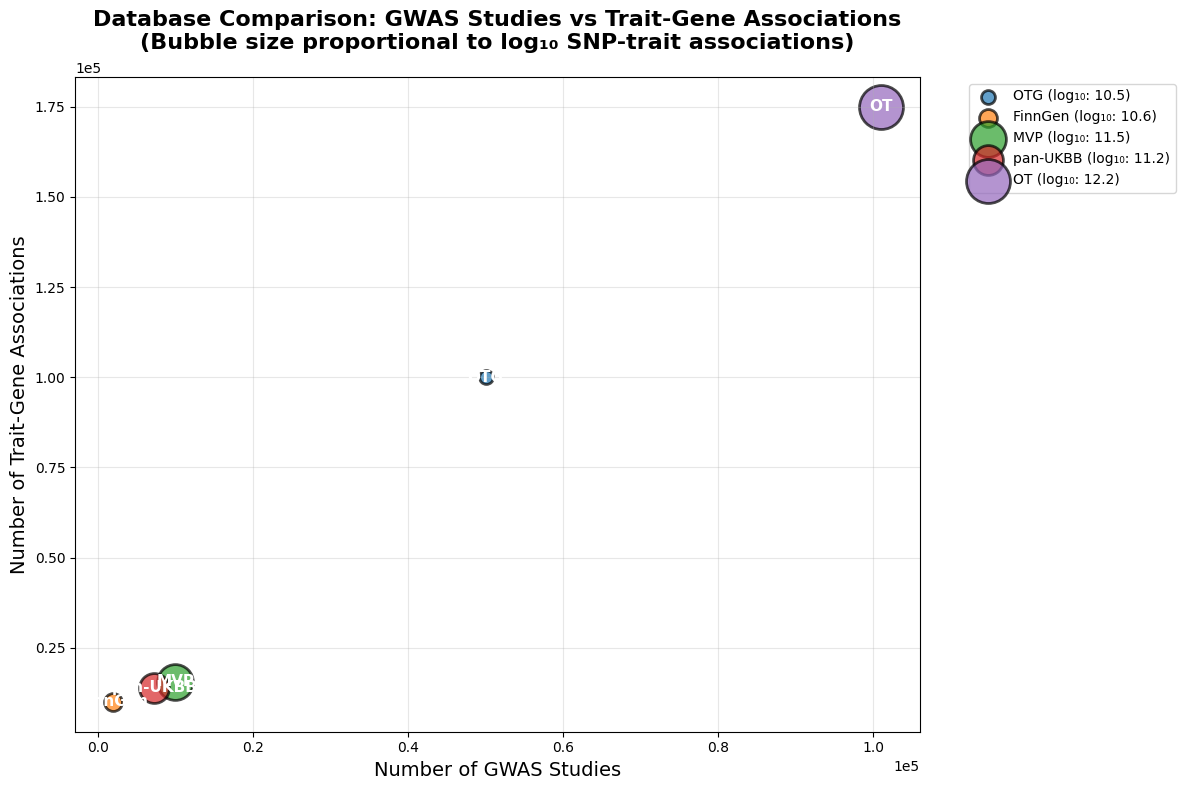

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the data
data = {
    'DB': ['OTG', 'FinnGen', 'MVP', 'pan-UKBB', 'OT'],
    'N_GWAS': [50000, 2000, 10000, 7266, 101000],
    'N_CS': [110000, 21000, 100000, 71372, 700000],
    'N_trait_genes': [100000, 10000, 15596, 14000, 175000],
    'N_SNP_trait_associations': [30000000000, 40000000000, 350000000000, 145320000000, 1515000000000]
}

df = pd.DataFrame(data)

# Calculate log of SNP-trait associations for bubble size
df['log_SNP_trait'] = np.log10(df['N_SNP_trait_associations'])

# Normalize bubble sizes (scale between 100 and 1000)
min_size, max_size = 100, 1000
df['bubble_size'] = ((df['log_SNP_trait'] - df['log_SNP_trait'].min()) / 
                     (df['log_SNP_trait'].max() - df['log_SNP_trait'].min())) * (max_size - min_size) + min_size

# Create the bubble plot
plt.figure(figsize=(12, 8))

# Define colors for each database
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Create scatter plot
for i, row in df.iterrows():
    plt.scatter(row['N_GWAS'], row['N_trait_genes'], 
               s=row['bubble_size'],
               alpha=0.7,
               color=colors[i],
               edgecolors='black',
               linewidth=2,
               label=f"{row['DB']} (log₁₀: {row['log_SNP_trait']:.1f})")

# Add labels for each bubble
for i, row in df.iterrows():
    plt.annotate(row['DB'], 
                (row['N_GWAS'], row['N_trait_genes']),
                xytext=(0, 0), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold',
                ha='center',
                va='center',
                color='white')

# Formatting
plt.xlabel('Number of GWAS Studies', fontsize=14)
plt.ylabel('Number of Trait-Gene Associations', fontsize=14)
plt.title('Database Comparison: GWAS Studies vs Trait-Gene Associations\n(Bubble size proportional to log₁₀ SNP-trait associations)', 
          fontsize=16, fontweight='bold', pad=20)

# Format axes
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

# Add grid
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout
plt.tight_layout()
plt.show()

Bubble sizes:
OTG: 11351 (log₁₀: 11.88)
FinnGen: 2000 (log₁₀: 10.60)
MVP: 4698 (log₁₀: 11.54)
pan-UKBB: 2534 (log₁₀: 11.16)
OT: 30000 (log₁₀: 12.18)


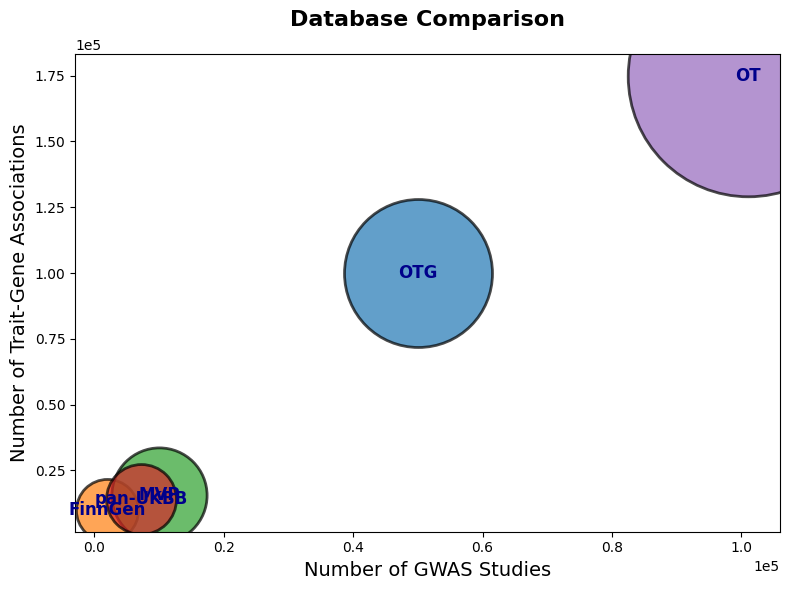

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the data
data = {
    'DB': ['OTG', 'FinnGen', 'MVP', 'pan-UKBB', 'OT'],
    'N_GWAS': [50000, 2000, 10000, 7266, 101000],
    'N_CS': [110000, 21000, 100000, 71372, 700000],
    'N_trait_genes': [100000, 10000, 15596, 14000, 175000],
    'N_SNP_trait_associations': [750000000000, 40000000000, 350000000000, 145320000000, 1515000000000]
}

df = pd.DataFrame(data)

# Calculate log of SNP-trait associations for bubble size
df['log_SNP_trait'] = np.log10(df['N_SNP_trait_associations'])

# Better scaling approach: use exponential scaling for more dramatic differences
min_size, max_size = 2000, 30000  # Increased range
df['bubble_size'] = min_size + (max_size - min_size) * np.power(
    (df['N_SNP_trait_associations'] - df['N_SNP_trait_associations'].min()) / 
    (df['N_SNP_trait_associations'].max() - df['N_SNP_trait_associations'].min()), 
    1.5  # Exponential factor for more dramatic scaling
)

# Alternative: Use square root scaling for more moderate differences
# df['bubble_size'] = min_size + (max_size - min_size) * np.sqrt(
#     (df['log_SNP_trait'] - df['log_SNP_trait'].min()) / 
#     (df['log_SNP_trait'].max() - df['log_SNP_trait'].min())
# )

# Create the bubble plot
plt.figure(figsize=(8, 6))

# Define colors for each database
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Create scatter plot
for i, row in df.iterrows():
    plt.scatter(row['N_GWAS'], row['N_trait_genes'], 
               s=row['bubble_size'],
               alpha=0.7,
               color=colors[i],
               edgecolors='black',
               linewidth=2,
               label=f"{row['DB']} (log₁₀: {row['log_SNP_trait']:.1f})")

# Add labels for each bubble
for i, row in df.iterrows():
    plt.annotate(row['DB'], 
                (row['N_GWAS'], row['N_trait_genes']),
                xytext=(0, 0), 
                textcoords='offset points',
                fontsize=12,
                fontweight='bold',
                ha='center',
                va='center',
                color='darkblue')

# Formatting
plt.xlabel('Number of GWAS Studies', fontsize=14)
plt.ylabel('Number of Trait-Gene Associations', fontsize=14)
plt.title('Database Comparison', 
          fontsize=16, fontweight='bold', pad=20)

# Format axes
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

# Add grid
#plt.grid(True, alpha=0.3)

# Add legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout
plt.tight_layout()

# Print bubble sizes for reference
print("Bubble sizes:")
for i, row in df.iterrows():
    print(f"{row['DB']}: {row['bubble_size']:.0f} (log₁₀: {row['log_SNP_trait']:.2f})")

plt.show()

Bubble sizes:
OTG: 11351 (log₁₀: 11.88)
FinnGen: 2000 (log₁₀: 10.60)
MVP: 4698 (log₁₀: 11.54)
pan-UKBB: 2534 (log₁₀: 11.16)
OT: 30000 (log₁₀: 12.18)


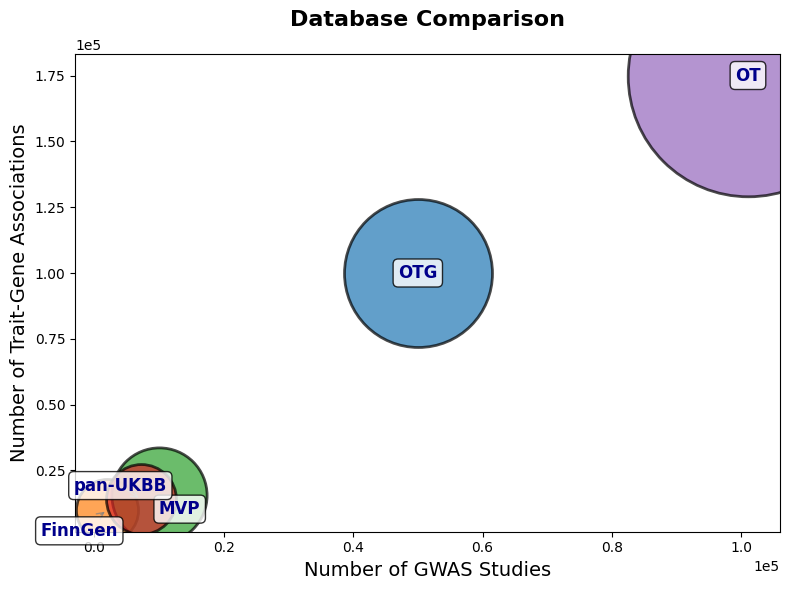

25/10/07 03:06:28 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 847885 ms exceeds timeout 120000 ms
25/10/07 03:06:28 WARN SparkContext: Killing executors is not supported by current scheduler.
25/10/07 03:06:32 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Create the data
data = {
    'DB': ['OTG', 'FinnGen', 'MVP', 'pan-UKBB', 'OT'],
    'N_GWAS': [50000, 2000, 10000, 7266, 101000],
    'N_CS': [110000, 21000, 100000, 71372, 700000],
    'N_trait_genes': [100000, 10000, 15596, 14000, 175000],
    'N_SNP_trait_associations': [750000000000, 40000000000, 350000000000, 145320000000, 1515000000000]
}

df = pd.DataFrame(data)

# Calculate log of SNP-trait associations for bubble size
df['log_SNP_trait'] = np.log10(df['N_SNP_trait_associations'])

# Better scaling approach: use exponential scaling for more dramatic differences
min_size, max_size = 2000, 30000  # Increased range
df['bubble_size'] = min_size + (max_size - min_size) * np.power(
    (df['N_SNP_trait_associations'] - df['N_SNP_trait_associations'].min()) / 
    (df['N_SNP_trait_associations'].max() - df['N_SNP_trait_associations'].min()), 
    1.5  # Exponential factor for more dramatic scaling
)

# Create the bubble plot
plt.figure(figsize=(8, 6))

# Define colors for each database
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

# Define custom offsets for each label to avoid overlap
offsets = [
    (0, 0),   # OTG - right and up
    (-20, -15), # FinnGen - left and down
    (15, -10),  # MVP - right and down
    (-15, 10),  # pan-UKBB - left and up
    (0, 0)     # OT - centered and up
]

# Create scatter plot
for i, row in df.iterrows():
    plt.scatter(row['N_GWAS'], row['N_trait_genes'], 
               s=row['bubble_size'],
               alpha=0.7,
               color=colors[i],
               edgecolors='black',
               linewidth=2,
               label=f"{row['DB']} (log₁₀: {row['log_SNP_trait']:.1f})")

# Add labels for each bubble with custom offsets
for i, row in df.iterrows():
    plt.annotate(row['DB'], 
                (row['N_GWAS'], row['N_trait_genes']),
                xytext=offsets[i], 
                textcoords='offset points',
                fontsize=12,
                fontweight='bold',
                ha='center',
                va='center',
                color='darkblue',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='gray', alpha=0.7))

# Formatting
plt.xlabel('Number of GWAS Studies', fontsize=14)
plt.ylabel('Number of Trait-Gene Associations', fontsize=14)
plt.title('Database Comparison', 
          fontsize=16, fontweight='bold', pad=20)

# Format axes
plt.ticklabel_format(style='scientific', axis='both', scilimits=(0,0))

# Add grid
#plt.grid(True, alpha=0.3)

# Add legend
#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Adjust layout
plt.tight_layout()

# Print bubble sizes for reference
print("Bubble sizes:")
for i, row in df.iterrows():
    print(f"{row['DB']}: {row['bubble_size']:.0f} (log₁₀: {row['log_SNP_trait']:.2f})")

plt.show()